# 연령별 인구 분포 비교 분석
- 행정안전부 주민등록 인구 통계: https://jumin.mois.go.kr/
- 행정동별 연령별 인구현황
- 현재 6년간씩 조회가능할것 2009 ~ 2025
- 히트맵을 만들 것.
- 전처리를 직접하고 , 시각화만 Ai 사용가능

Text(0.2, 0.4, '한글')

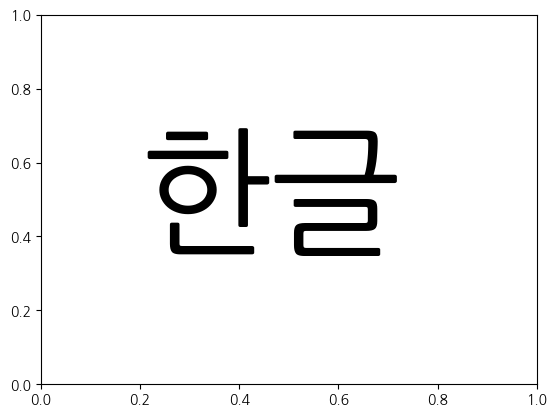

In [248]:
from hdfs import InsecureClient
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc('font', family='NanumGothic')
plt.text(0.2, 0.4, '한글', size=100)

In [249]:
# hdfs 업로드 실습
hdfs = InsecureClient('http://namenode:9870',user='hadoop')
# 파일 업로드 (Create)
print("\n[3] 파일 업로드")
local_files = ['/home/jovyan/work/dataset/200912_201412연령별인구현황연간.csv','/home/jovyan/work/dataset/201512_202012연령별인구현황연간.csv','/home/jovyan/work/dataset/202112_202512연령별인구현황연간.csv']
hdfs_files = ['/dataset/hdfs200912_201412연령별인구현황연간.csv','/dataset/hdfs201512_202012연령별인구현황연간.csv','/dataset/hdfs202112_202512연령별인구현황연간.csv']
for local, hdfs_path in zip(local_files, hdfs_files):
    hdfs.upload(hdfs_path, local, overwrite=True)
    print(f"  업로드 완료: {hdfs_path}")


[3] 파일 업로드
  업로드 완료: /dataset/hdfs200912_201412연령별인구현황연간.csv
  업로드 완료: /dataset/hdfs201512_202012연령별인구현황연간.csv
  업로드 완료: /dataset/hdfs202112_202512연령별인구현황연간.csv


In [273]:
hdfs_files = [
    '/dataset/hdfs200912_201412연령별인구현황연간.csv',
    '/dataset/hdfs201512_202012연령별인구현황연간.csv',
    '/dataset/hdfs202112_202512연령별인구현황연간.csv'
]

dfs = []
for hdfs_file in hdfs_files:
    with hdfs.read(hdfs_file, encoding='EUC-KR') as reader:
        df = pd.read_csv(reader)
        dfs.append(df)

# 여러 DataFrame을 하나로 합치기
population = pd.concat(dfs, ignore_index=True)

# print(population.head())

mdata = pd.merge(dfs[0], dfs[1], on="행정구역", how="left")
data = pd.merge(mdata, dfs[2], on="행정구역", how="left")
data.head(3)

,행정구역,2009년_계_총인구수,2009년_계_연령구간인구수,2009년_계_0~9세,2009년_계_10~19세,2009년_계_20~29세,2009년_계_30~39세,2009년_계_40~49세,2009년_계_50~59세,2009년_계_60~69세,...,2025년_여_10~19세,2025년_여_20~29세,2025년_여_30~39세,2025년_여_40~49세,2025년_여_50~59세,2025년_여_60~69세,2025년_여_70~79세,2025년_여_80~89세,2025년_여_90~99세,2025년_여_100세 이상
0,전국 (0000000000),"49,773,145","49,773,145","4,922,969","6,811,650","7,028,262","8,371,533","8,729,495","6,508,077","4,047,492",...,"2,252,500","2,731,714","3,183,648","3,722,461","4,279,301","4,015,237","2,434,888","1,334,492","276,634","7,285"
1,서울특별시 (1100000000),"10,208,302","10,208,302","898,116","1,259,471","1,641,530","1,877,265","1,724,937","1,398,666","854,162",...,"351,202","668,158","731,594","690,464","745,790","693,675","454,809","217,852","39,589","1,122"
2,부산광역시 (2600000000),"3,543,030","3,543,030","282,560","454,929","523,221","541,448","614,657","560,978","338,206",...,"129,117","166,150","187,510","227,270","269,150","293,502","200,839","93,279","15,912",380


In [274]:
data = data[data.columns[data.columns.str.contains("행정구역|년_남_|년_여_")]]
data = data[data.columns[~data.columns.str.contains("_총인구수|_연령구간인구수")]] # 물결 '~' 표시는 반대값
data

,행정구역,2009년_남_0~9세,2009년_남_10~19세,2009년_남_20~29세,2009년_남_30~39세,2009년_남_40~49세,2009년_남_50~59세,2009년_남_60~69세,2009년_남_70~79세,2009년_남_80~89세,...,2025년_여_10~19세,2025년_여_20~29세,2025년_여_30~39세,2025년_여_40~49세,2025년_여_50~59세,2025년_여_60~69세,2025년_여_70~79세,2025년_여_80~89세,2025년_여_90~99세,2025년_여_100세 이상
0,전국 (0000000000),"2,553,592","3,599,148","3,636,509","4,269,498","4,439,164","3,261,648","1,920,187","997,027","233,278",...,"2,252,500","2,731,714","3,183,648","3,722,461","4,279,301","4,015,237","2,434,888","1,334,492","276,634","7,285"
1,서울특별시 (1100000000),"463,335","661,712","816,567","955,372","856,086","676,233","413,754","174,395","38,116",...,"351,202","668,158","731,594","690,464","745,790","693,675","454,809","217,852","39,589","1,122"
2,부산광역시 (2600000000),"146,683","244,690","271,470","274,548","300,525","274,985","163,497","70,306","13,610",...,"129,117","166,150","187,510","227,270","269,150","293,502","200,839","93,279","15,912",380
3,대구광역시 (2700000000),"122,461","198,747","186,090","197,688","224,441","166,867","92,401","45,344","9,211",...,"103,673","120,683","132,982","168,373","211,040","198,463","123,774","64,137","11,751",244
4,인천광역시 (2800000000),"141,013","205,211","203,364","237,071","259,668","177,446","89,029","40,962","10,086",...,"134,628","163,718","206,089","229,629","257,977","240,110","125,153","63,740","13,996",458
5,광주광역시 (2900000000),"83,426","120,595","106,793","121,172","121,742","80,661","48,520","22,416","5,379",...,"69,794","81,483","83,278","106,651","121,311","101,060","61,179","31,734","6,292",166
6,대전광역시 (3000000000),"82,380","117,622","113,206","127,410","131,284","93,346","48,464","23,255","5,647",...,"65,946","89,881","91,114","104,303","121,309","107,446","62,207","31,741","6,550",176
7,울산광역시 (3100000000),"62,367","95,536","84,136","94,990","112,018","75,969","33,286","12,686","2,438",...,"52,823","46,580","61,167","81,241","98,972","88,639","44,472","18,631","3,489",89
8,세종특별자치시 (3600000000),0,0,0,0,0,0,0,0,0,...,"26,728","17,838","29,199","38,974","28,381","19,862","10,228","5,194","1,395",32
9,경기도 (4100000000),"668,710","863,173","800,560","1,059,189","1,100,203","689,154","359,518","185,246","43,796",...,"648,817","742,934","915,920","1,068,642","1,170,928","986,112","527,550","279,834","58,507","1,633"


In [275]:
data = data.melt(id_vars=['행정구역'], var_name='타입', value_name ='value')
data

,행정구역,타입,value
0,전국 (0000000000),2009년_남_0~9세,"2,553,592"
1,서울특별시 (1100000000),2009년_남_0~9세,"463,335"
2,부산광역시 (2600000000),2009년_남_0~9세,"146,683"
3,대구광역시 (2700000000),2009년_남_0~9세,"122,461"
4,인천광역시 (2800000000),2009년_남_0~9세,"141,013"
...,...,...,...
6727,전라북도 (4500000000),2025년_여_100세 이상,0
6728,전라남도 (4600000000),2025년_여_100세 이상,462
6729,경상북도 (4700000000),2025년_여_100세 이상,499
6730,경상남도 (4800000000),2025년_여_100세 이상,447


In [276]:
test1 = data['타입'].str.split('_')
print(type(test1),test1)
test2 = data['타입'].str.split('_',expand=True)
print(type(test2),test2)
data[['time','gender','age']] = data['타입'].str.split('_',expand=True)
del data['타입']
data.head(5)

<class 'pandas.Series'> 0          [2009년, 남, 0~9세]
1          [2009년, 남, 0~9세]
2          [2009년, 남, 0~9세]
3          [2009년, 남, 0~9세]
4          [2009년, 남, 0~9세]
               ...         
6727    [2025년, 여, 100세 이상]
6728    [2025년, 여, 100세 이상]
6729    [2025년, 여, 100세 이상]
6730    [2025년, 여, 100세 이상]
6731    [2025년, 여, 100세 이상]
Name: 타입, Length: 6732, dtype: object
<class 'pandas.DataFrame'>           0  1        2
0     2009년  남     0~9세
1     2009년  남     0~9세
2     2009년  남     0~9세
3     2009년  남     0~9세
4     2009년  남     0~9세
...     ... ..      ...
6727  2025년  여  100세 이상
6728  2025년  여  100세 이상
6729  2025년  여  100세 이상
6730  2025년  여  100세 이상
6731  2025년  여  100세 이상

[6732 rows x 3 columns]


,행정구역,value,time,gender,age
0,전국 (0000000000),"2,553,592",2009년,남,0~9세
1,서울특별시 (1100000000),"463,335",2009년,남,0~9세
2,부산광역시 (2600000000),"146,683",2009년,남,0~9세
3,대구광역시 (2700000000),"122,461",2009년,남,0~9세
4,인천광역시 (2800000000),"141,013",2009년,남,0~9세


In [277]:
new_data = data.copy()
new_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6732 entries, 0 to 6731
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   행정구역    6732 non-null   str   
 1   value   6732 non-null   object
 2   time    6732 non-null   str   
 3   gender  6732 non-null   str   
 4   age     6732 non-null   str   
dtypes: object(1), str(4)
memory usage: 564.0+ KB


In [278]:
new_data['value'].dtype

dtype('O')

In [279]:
new_data['value'] = new_data['value'].str.replace(',','').fillna(0).astype(int)
new_data.head(3)

,행정구역,value,time,gender,age
0,전국 (0000000000),2553592,2009년,남,0~9세
1,서울특별시 (1100000000),463335,2009년,남,0~9세
2,부산광역시 (2600000000),146683,2009년,남,0~9세


In [280]:
print(new_data['value'].dtype,new_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 6732 entries, 0 to 6731
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   행정구역    6732 non-null   str  
 1   value   6732 non-null   int64
 2   time    6732 non-null   str  
 3   gender  6732 non-null   str  
 4   age     6732 non-null   str  
dtypes: int64(1), str(4)
memory usage: 564.0 KB
int64 None


In [281]:
new_data['time'] = pd.to_datetime(new_data['time'], format="%Y년")
new_data.head(3)

,행정구역,value,time,gender,age
0,전국 (0000000000),2553592,2009-01-01,남,0~9세
1,서울특별시 (1100000000),463335,2009-01-01,남,0~9세
2,부산광역시 (2600000000),146683,2009-01-01,남,0~9세


In [282]:
# new_data = new_data.drop(new_data.iloc[0:1].index)
new_data = new_data.drop(new_data[new_data['행정구역'] == '전국  '].index)
new_data.head(3)

,행정구역,value,time,gender,age
0,전국 (0000000000),2553592,2009-01-01,남,0~9세
1,서울특별시 (1100000000),463335,2009-01-01,남,0~9세
2,부산광역시 (2600000000),146683,2009-01-01,남,0~9세


In [307]:
getdata = new_data.copy()
mydata = new_data.copy()
mydata

,행정구역,value,time,gender,age
0,전국 (0000000000),2553592,2009-01-01,남,0~9세
1,서울특별시 (1100000000),463335,2009-01-01,남,0~9세
2,부산광역시 (2600000000),146683,2009-01-01,남,0~9세
3,대구광역시 (2700000000),122461,2009-01-01,남,0~9세
4,인천광역시 (2800000000),141013,2009-01-01,남,0~9세
...,...,...,...,...,...
6727,전라북도 (4500000000),0,2025-01-01,여,100세 이상
6728,전라남도 (4600000000),462,2025-01-01,여,100세 이상
6729,경상북도 (4700000000),499,2025-01-01,여,100세 이상
6730,경상남도 (4800000000),447,2025-01-01,여,100세 이상


In [308]:
mydata = mydata[~mydata['행정구역'].str.contains('전국')]
mydata['행정구역'] = mydata['행정구역'].str.replace(r'\s*\(\d+\)', '', regex=True).str.strip()
mydata.head()

,행정구역,value,time,gender,age
1,서울특별시,463335,2009-01-01,남,0~9세
2,부산광역시,146683,2009-01-01,남,0~9세
3,대구광역시,122461,2009-01-01,남,0~9세
4,인천광역시,141013,2009-01-01,남,0~9세
5,광주광역시,83426,2009-01-01,남,0~9세


In [309]:
mydata2 = mydata.groupby(['행정구역','gender','time','age'])['value'].sum().reset_index()
mydata2.head(15)

,행정구역,gender,time,age,value
0,강원도,남,2009-01-01,0~9세,74150
1,강원도,남,2009-01-01,100세 이상,0
2,강원도,남,2009-01-01,10~19세,104478
3,강원도,남,2009-01-01,20~29세,103650
4,강원도,남,2009-01-01,30~39세,114317
5,강원도,남,2009-01-01,40~49세,133334
6,강원도,남,2009-01-01,50~59세,107888
7,강원도,남,2009-01-01,60~69세,70133
8,강원도,남,2009-01-01,70~79세,41836
9,강원도,남,2009-01-01,80~89세,10293


In [310]:
mydata2 = mydata2.dropna()
mydata2.sample(5)

,행정구역,gender,time,age,value
950,경상남도,여,2010-01-01,30~39세,254766
1686,광주광역시,여,2009-01-01,20~29세,102970
603,경기도,여,2012-01-01,80~89세,122666
2709,부산광역시,남,2017-01-01,20~29세,237994
4476,인천광역시,여,2024-01-01,90~99세,12706


In [311]:
mydata2 = mydata2.dropna()
mydata2.head(12)

,행정구역,gender,time,age,value
0,강원도,남,2009-01-01,0~9세,74150
1,강원도,남,2009-01-01,100세 이상,0
2,강원도,남,2009-01-01,10~19세,104478
3,강원도,남,2009-01-01,20~29세,103650
4,강원도,남,2009-01-01,30~39세,114317
5,강원도,남,2009-01-01,40~49세,133334
6,강원도,남,2009-01-01,50~59세,107888
7,강원도,남,2009-01-01,60~69세,70133
8,강원도,남,2009-01-01,70~79세,41836
9,강원도,남,2009-01-01,80~89세,10293


In [312]:
mydata3 = mydata2.groupby(['행정구역', 'time', 'age'])['value'].sum().reset_index()
mydata3.head()

,행정구역,time,age,value
0,강원도,2009-01-01,0~9세,142407
1,강원도,2009-01-01,100세 이상,101
2,강원도,2009-01-01,10~19세,198882
3,강원도,2009-01-01,20~29세,190738
4,강원도,2009-01-01,30~39세,220593


In [313]:
piv_data = mydata3.pivot_table(
    index=["행정구역", "time"],
    columns="age",
    values="value", 
    aggfunc="sum"
)
piv_data

age                0~9세  100세 이상  10~19세  20~29세  30~39세  40~49세  50~59세  \
행정구역 time                                                                  
강원도  2009-01-01  142407      101  198882  190738  220593  257661  213025   
     2010-01-01  136122      408  199370  186250  218443  257895  232650   
     2011-01-01  132030      429  197384  183798  213295  255010  250600   
     2012-01-01  129660      478  191577  180716  208796  252053  256968   
     2013-01-01  126868      523  185598  180364  202244  253169  264144   
...                 ...      ...     ...     ...     ...     ...     ...   
충청북도 2021-01-01  116975      268  146411  194415  190607  237327  270874   
     2022-01-01  109410      279  145882  188310  187432  236190  268313   
     2023-01-01  103333      256  144446  181676  187761  230702  272450   
     2024-01-01   97837      284  142996  173746  189274  225024  273441   
     2025-01-01   93256      317  143242  166917  193236  221812  271167   

age              60~69세  70~79세  80~89세  90~99세  
행정구역 time                                        
강원도  2009-01-01  149139  102056   33824    4412  
     2010-01-01  148498  108522   36595    5065  
     2011-01-01  145091  115060   38376    5375  
     2012-01-01  149499  122786   40264    5833  
     2013-01-01  153150  127008   42723    6472  
...                 ...     ...     ...     ...  
충청북도 2021-01-01  241697  120068   69193    9592  
     2022-01-01  251466  123834   73755   10187  
     2023-01-01  257982  128433   75249   11181  
     2024-01-01  264085  135995   76117   12378  
     2025-01-01  269755  147206   75788   13806  

[289 rows x 11 columns]

In [314]:
templist = list(piv_data.columns)
templist.append(templist.pop(1))
piv_data = piv_data[templist]
piv_data

age                0~9세  10~19세  20~29세  30~39세  40~49세  50~59세  60~69세  \
행정구역 time                                                                 
강원도  2009-01-01  142407  198882  190738  220593  257661  213025  149139   
     2010-01-01  136122  199370  186250  218443  257895  232650  148498   
     2011-01-01  132030  197384  183798  213295  255010  250600  145091   
     2012-01-01  129660  191577  180716  208796  252053  256968  149499   
     2013-01-01  126868  185598  180364  202244  253169  264144  153150   
...                 ...     ...     ...     ...     ...     ...     ...   
충청북도 2021-01-01  116975  146411  194415  190607  237327  270874  241697   
     2022-01-01  109410  145882  188310  187432  236190  268313  251466   
     2023-01-01  103333  144446  181676  187761  230702  272450  257982   
     2024-01-01   97837  142996  173746  189274  225024  273441  264085   
     2025-01-01   93256  143242  166917  193236  221812  271167  269755   

age              70~79세  80~89세  90~99세  100세 이상  
행정구역 time                                         
강원도  2009-01-01  102056   33824    4412      101  
     2010-01-01  108522   36595    5065      408  
     2011-01-01  115060   38376    5375      429  
     2012-01-01  122786   40264    5833      478  
     2013-01-01  127008   42723    6472      523  
...                 ...     ...     ...      ...  
충청북도 2021-01-01  120068   69193    9592      268  
     2022-01-01  123834   73755   10187      279  
     2023-01-01  128433   75249   11181      256  
     2024-01-01  135995   76117   12378      284  
     2025-01-01  147206   75788   13806      317  

[289 rows x 11 columns]

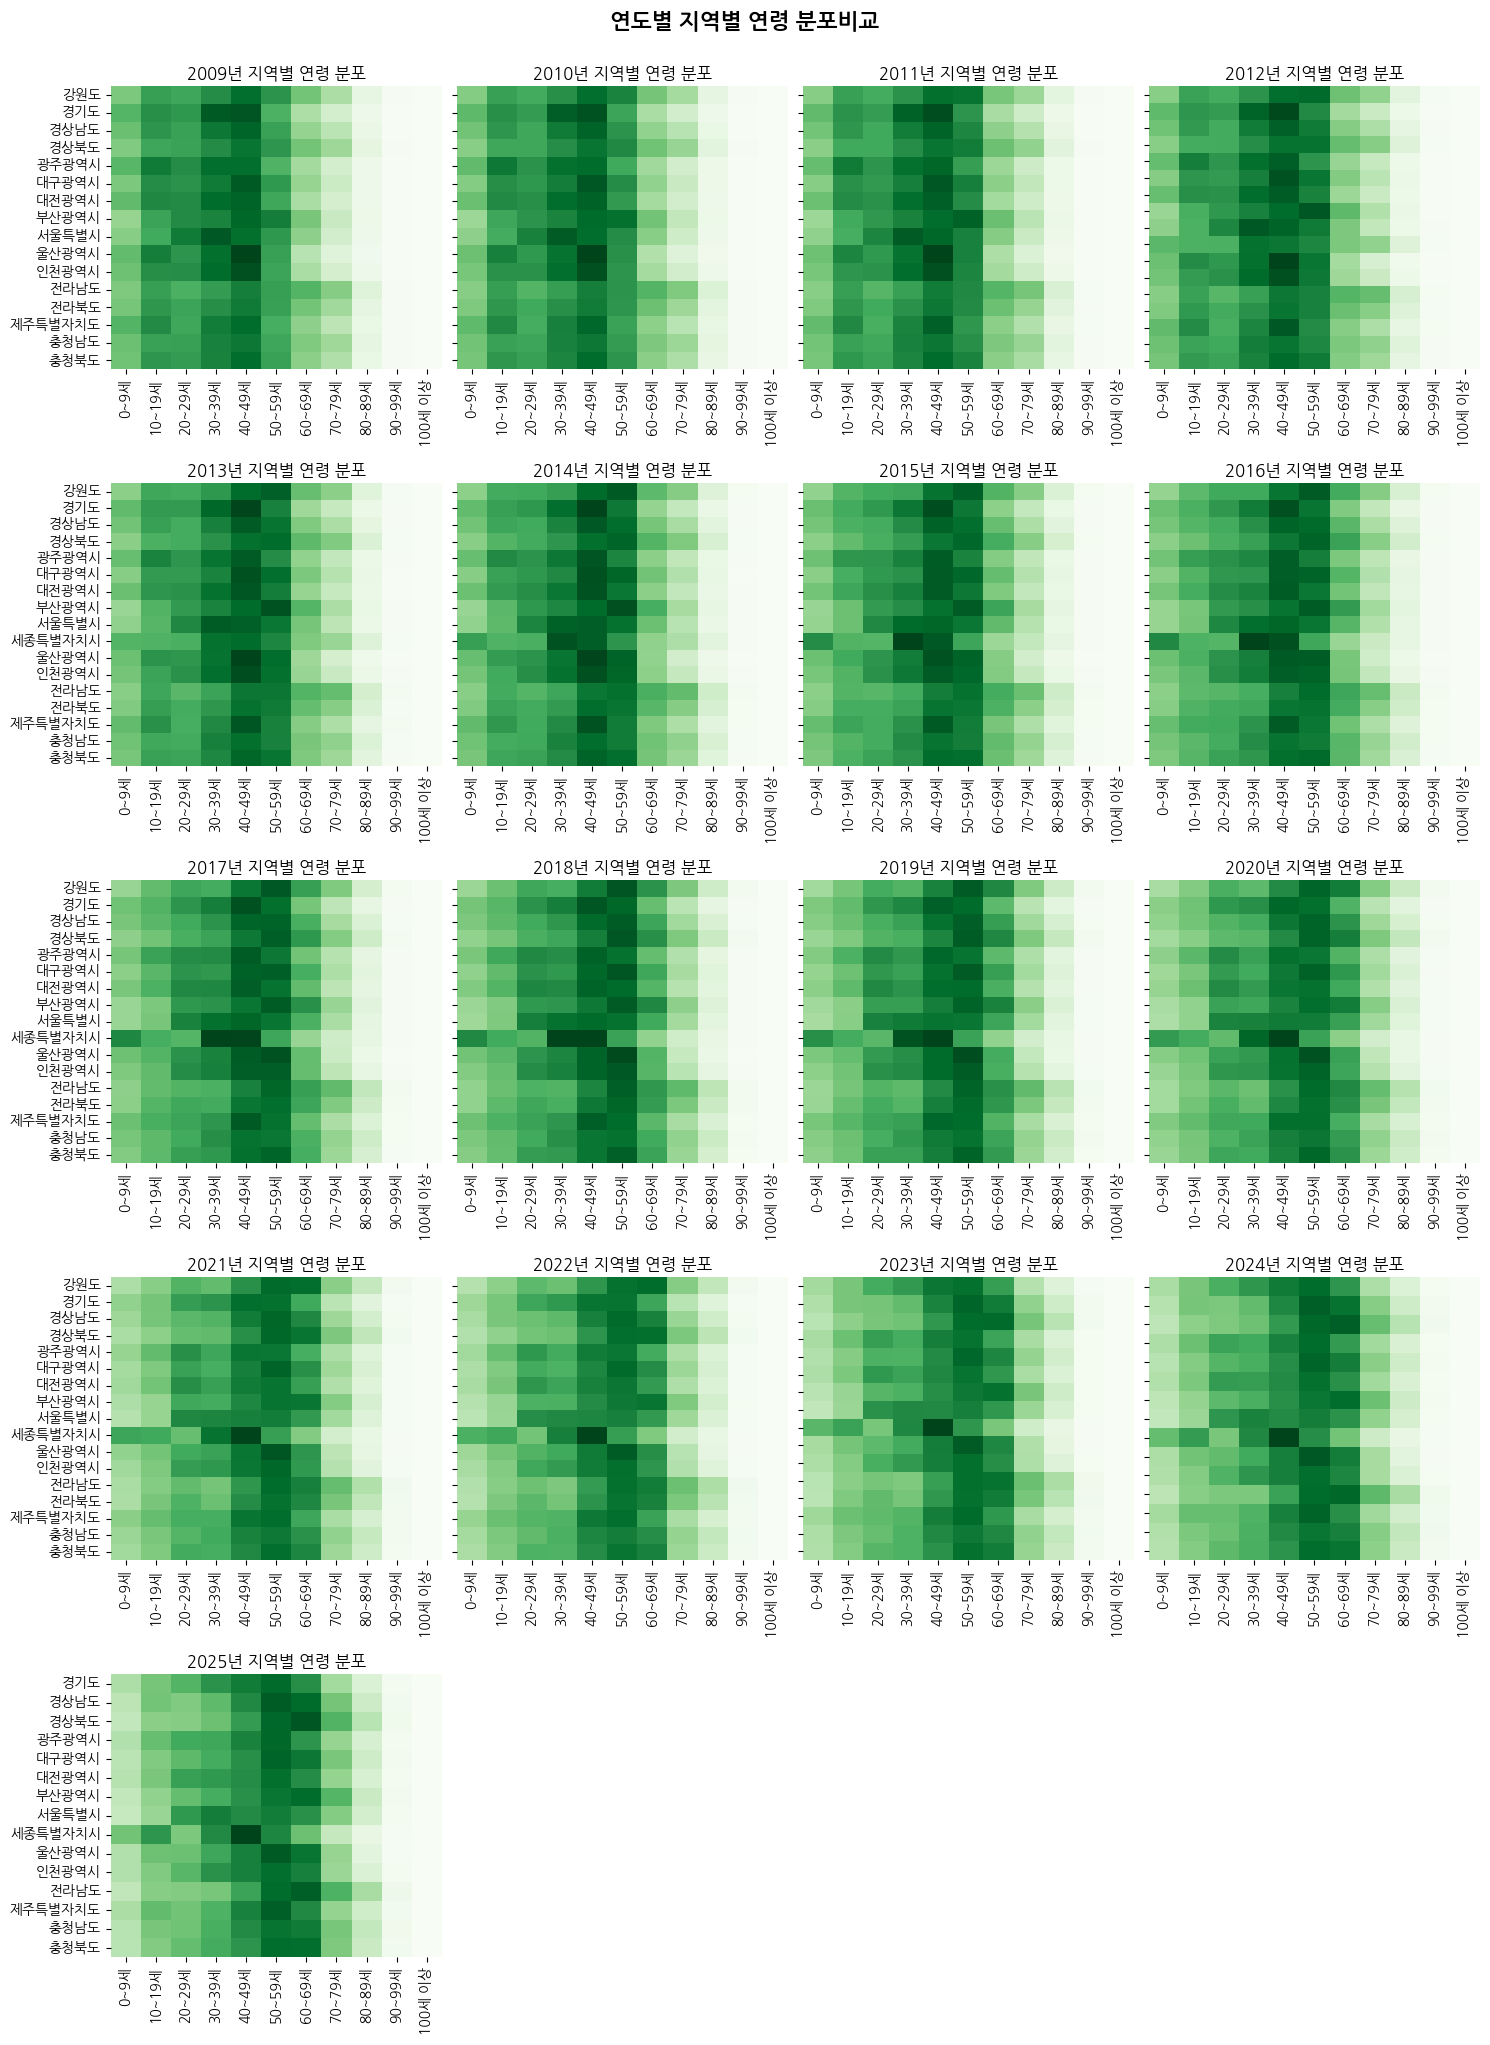

In [322]:
import numpy as np

# 1. 서브플롯 설정
fig, axes = plt.subplots(5, 4, figsize=(15, 20))
axes_flat = axes.flatten()

# 2. 데이터 전처리 및 히트맵 그리기 함수
def draw_heatmap(year, ax):
    # 인덱스(행정구역, time)를 컬럼으로 복원
    def_data = piv_data.reset_index().copy()
    
    # 해당 연도만 필터링 (time이 문자열/날짜 형식이든 변환하여 처리)
    def_data = def_data[def_data['time'].astype(str).str.contains(str(year))]
    
    if def_data.empty:
        ax.text(0.5, 0.5, '데이터 없음', ha='center', va='center')
        return

    # [중요] 피벗된 데이터를 다시 긴 형태로 변환하여 'age' 컬럼 생성
    def_data = def_data.melt(id_vars=['행정구역', 'time'], var_name='age', value_name='value')
    
    # 비율 계산 (각 행정구역별 총합 대비)
    def_data['value'] = def_data.groupby('행정구역')['value'].transform(lambda x: 100 * x / float(x.sum()))
    def_data = def_data.dropna()
    
    # 다시 히트맵용 피벗 생성
    piv_table2 = def_data.pivot(index='행정구역', columns='age', values='value')
    
    # 연령대 정렬 (숫자 순서)
    cols = piv_table2.columns.str.extract(r'(\d+)', expand=False).fillna(0).astype(int)
    piv_table2 = piv_table2.iloc[:, np.argsort(cols)]

    # 히트맵 그리기
    sns.heatmap(
        piv_table2.sort_index(axis=0), 
        ax=ax, 
        cmap='Greens', 
        annot=False, 
        cbar=False,

    )
    
    ax.set_title(f"{year}년 지역별 연령 분포", fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # 맨 왼쪽 열이 아니면 y축 라벨 숨기기
    if (list(axes_flat).index(ax) % 4 != 0):
        ax.set_yticklabels([])

# 3. 각 연도별 실행
years = list(range(2009, 2026)) 

for idx, year in enumerate(years):
    if idx < len(axes_flat):
        draw_heatmap(year, axes_flat[idx])

# 남는 칸 숨기기
for j in range(len(years), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.suptitle('연도별 지역별 연령 분포비교', fontsize=16, fontweight='bold', y=1.02)
plt.show()